# TLDR: Too Long Didn't Read

Each section below is a self-contained minimal example: copy-paste any single code cell into a fresh kernel and it will reproduce the figure without relying on any other cell in this notebook.

The examples exclusively focus on the plot-misc plotting capabilities, for more detailed exposition, including relevant data preparation steps, please consult the module specific notebooks. 

## Barchart

Bar charts display categorical data as rectangular bars with heights proportional to the values; `plot_misc.barchart` supports simple, grouped, and stacked variants.


### Simple bar chart

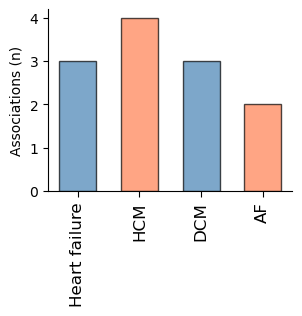

In [1]:
import matplotlib.pyplot as plt

import plot_misc.barchart as barchart
import plot_misc.example_data.examples as examples

CMTOINCH = 1 / 2.54

# get data
table = examples.get_data("load_barchart_preprocessed")

# plotting
_, ax = barchart.bar(
    table,
    label="labels",
    column="RV",
    wd=0.6,
    colours=['steelblue', 'coral',],
    figsize=(8 * CMTOINCH, 6 * CMTOINCH),
)
# formatting
ax.tick_params(
    axis="x",
    labelsize=12,
    length=4,
    rotation=90,
)
_ = ax.set_ylabel("Associations (n)")

### Grouped bar chart

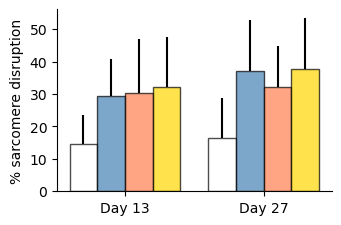

In [2]:
import matplotlib.pyplot as plt

import plot_misc.barchart as barchart
import plot_misc.example_data.examples as examples

CMTOINCH = 1 / 2.54

# get data
group_table = examples.get_data("load_groupbar_preprocessed")
cols = ["Control", "AP4S1", "LRRC39", "ZFAND4"]

# plotting
_, ax = barchart.group_bar(
    group_table,
    label="Age",
    columns=[c + "_mean" for c in cols],
    errors_max=[c + "_max" for c in cols],
    colours=["white", "steelblue", "coral", "gold"],
    wd=0.2,
    figsize=(9 * CMTOINCH, 6 * CMTOINCH),
)
_ = ax.set_ylabel("% sarcomere disruption")

### Stacked bar chart

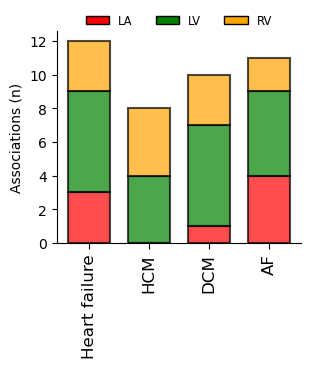

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import plot_misc.barchart as barchart
import plot_misc.example_data.examples as examples

CMTOINCH = 1 / 2.54
COLOURS = ["red", "green", "orange"]

# get data
table = examples.load_barchart_preprocessed()

# plotting
_, ax = barchart.stack_bar(
    table,
    label="labels",
    columns=table.columns[:-1].to_list(),
    wd=0.7,
    colours=COLOURS,
    figsize=(8 * CMTOINCH, 7 * CMTOINCH),
    **{"linewidth": 1.5},
)

# axis formatting
ax.tick_params(
    axis="x",
    labelsize=12,
    length=4,
    rotation=90,
)
_ = ax.set_ylabel("Associations (n)")

# add legend
cmap = dict(zip(list(table.columns[:-1]), COLOURS))
patches = [
    Patch(facecolor=v, label=k, edgecolor="black") for k, v in cmap.items()
]
_ = ax.legend(
    handles=patches,
    ncol=3,
    loc='center',
    bbox_to_anchor=(0.5, 1.05),
    fontsize="small",
    frameon=False,
)

### Bar chart with a total and subtotal column

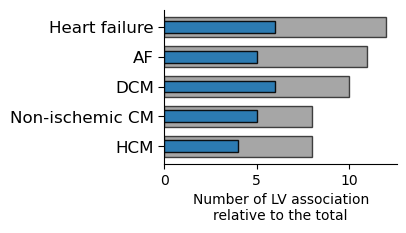

In [9]:
import matplotlib.pyplot as plt

import plot_misc.barchart as barchart
import plot_misc.example_data.examples as examples

# get data
table = examples.load_subtotal_preprocessed()

# plotting the graph - using horizontal positioning
_, ax = barchart.subtotal_bar(
    table,
    label="labels",
    total_col="total",
    subtotal_col="sub",
    wd=(0.7, 0.4),
    figsize=(3, 2),
    horizontal=True,
)
ax.tick_params(
    axis="y",
    labelsize=12.0,
    length=4,
)
_= ax.set_xlabel("Number of LV association\nrelative to the total")

## Forest

Forest plots display point estimates with confidence intervals, commonly used in meta-analyses and clinical studies.

In [ ]:
# Forest plot — hazard ratios with side table
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import plot_misc.forest as forest
from plot_misc import utils as plm_utils
from plot_misc.utils.utils import annotate_axis_midpoints
import plot_misc.example_data.examples as examples

CMTOINCH = 1 / 2.54

data = examples.get_data('load_mace_associations')
dat = data[data['Exposure'] == 'LDL-C (mmol/L)'].reset_index()
dat = forest.set_y_coordinates(dat, group='Comparison', between_pad=4, within_pad=2)

fig = plt.figure(figsize=(10 * CMTOINCH, 6 * CMTOINCH))
gs = GridSpec(nrows=1, ncols=2, width_ratios=[6, 4], figure=fig)
ax_main = fig.add_subplot(gs[0, 0])
ax_table = fig.add_subplot(gs[0, 1])

trees = forest.ForestPlot(
    data=dat, x_col='coef', lb_col='coef lower 95%', ub_col='coef upper 95%',
    g_col='Model', ax=ax_main,
)
trees.plot(
    c_col='col', s_size_col=40, ci_lwd=0.8, ci_colour='black',
    span=False, reverse_y=True,
    kwargs_scatter_dict={'edgecolors': 'black', 'linewidth': 1.1, 'zorder': 2},
    kwargs_plot_ci_dict={'zorder': 0},
)
ax_table.set_ylim(ax_main.get_ylim())
forest.plot_table(
    dat, annoteheader='HR (95% CI)', string_col='string_estimates',
    halignment_text='center', halignment_header='center',
    size_text=7, size_header=6, negative_padding=1, ax=ax_table,
)
ax_main.spines[['right', 'top']].set_visible(False)
ax_main.axvline(0, linewidth=1, linestyle='--', c='black', zorder=0)
_ = annotate_axis_midpoints(
    labels=['ASCVD:', 'T2DM:', 'LLT:'], axis='y', gap=4, offset=-0.04,
    padding=0.35, ax=ax_main,
    text_kwargs={'fontsize': 6, 'fontweight': 'bold'},
)
ax_main.tick_params(axis='y', labelsize=7, length=2.5)
ax_main.set_xlim(np.log((0.90, 1.05)))
plm_utils.utils.change_ticks(ax_main, ticks=[0.90, 1.00, 1.05], log=True)
ax_main.set_xlabel('Hazard ratio (95% CI)', fontsize=6, labelpad=2)
old_ylim = ax_main.get_ylim()
ax_main.set_ylim(old_ylim[0] + 0.5, old_ylim[1] - 0.5)

## Heatmap

Heatmaps encode matrix values as colours; `plot_misc.heatmap` also supports annotating cells with formatted text.

In [ ]:
# Standard heatmap
import matplotlib as mpl
import matplotlib.pyplot as plt
import plot_misc.example_data.examples as examples
import plot_misc.heatmap as heatmap
import plot_misc.utils.utils as pm_utils

CMTOINCH = 1 / 2.54

matrix = examples.get_data('load_heatmap_data')
cmap = plt.get_cmap('PiYG', 13)
norm = pm_utils.MidpointNormalize(vcenter=0, vmin=-8, vmax=8)

fig, ax = plt.subplots(1, figsize=(8 * CMTOINCH, 8 * CMTOINCH))
im, _ = heatmap.heatmap(
    data=matrix,
    row_labels=matrix.index.to_list(),
    col_labels=matrix.columns.to_list(),
    ax=ax,
    cmap=cmap,
    norm=norm,
    grid_linewidth=1.5,
)
im.axes.tick_params(pad=1.5, length=3, bottom=True)
_ = im.axes.set_xticklabels(im.axes.get_xmajorticklabels(), rotation=90, va='center')

In [ ]:
# Annotated heatmap — capture im handle, then call annotate_heatmap
import matplotlib as mpl
import matplotlib.pyplot as plt
import plot_misc.example_data.examples as examples
import plot_misc.heatmap as heatmap
import plot_misc.utils.utils as pm_utils

CMTOINCH = 1 / 2.54

matrix = examples.get_data('load_heatmap_data')
cmap = plt.get_cmap('PiYG', 13)
norm = pm_utils.MidpointNormalize(vcenter=0, vmin=-8, vmax=8)

fig, ax = plt.subplots(1, figsize=(8 * CMTOINCH, 8 * CMTOINCH))
im, _ = heatmap.heatmap(
    data=matrix,
    row_labels=matrix.index.to_list(),
    col_labels=matrix.columns.to_list(),
    ax=ax,
    cmap=cmap,
    norm=norm,
    grid_linewidth=1.5,
)
texts = heatmap.annotate_heatmap(im, threshold=6, valfmt='{x:.1f}', fontsize=3)
im.axes.tick_params(pad=1.5, length=3, bottom=True)
_ = im.axes.set_xticklabels(im.axes.get_xmajorticklabels(), rotation=90, va='center')

## Incidencematrix

Incidence-matrix plots represent binary or categorical tables as dot grids, where colour and size encode category membership.

In [ ]:
# Incidence matrix
import numpy as np
import plot_misc.example_data.examples as examples
from plot_misc import incidencematrix as imat_plt

CMTOINCH = 1 / 2.54

data = examples.get_data('load_incidence_matrix_data').head(10)
del data['Counts']

f, ax = imat_plt.draw_incidencematrix(
    data,
    fsize=(4 * CMTOINCH, 5 * CMTOINCH),
    dot_colour=[('#C4C4C4', 0), ('#B12137', np.inf)],
    dot_size=[30, 90],
    lw=[1, 1],
    tick_lab_size=(8, 8),
    tick_len=[3, 3],
    margins=(0.06, 0.015),
    kwargs_scatter_dict={'edgecolor': 'black', 'linewidths': 0.8},
)

In [ ]:
# Bubble chart incidence matrix — dot size encodes row total (Counts)
import numpy as np
import plot_misc.example_data.examples as examples
from plot_misc import incidencematrix as imat_plt

CMTOINCH = 1 / 2.54

data = examples.get_data('load_incidence_matrix_data').head(10)
counts = data['Counts'].copy()
data = data.drop(columns=['Counts'])

# each present dot sized by the row's association count
size_data = data.multiply(counts, axis=0)

f, ax = imat_plt.draw_incidencematrix(
    data,
    size_data=size_data,
    fsize=(4 * CMTOINCH, 5 * CMTOINCH),
    dot_colour=[('#C4C4C4', 0), ('#B12137', np.inf)],
    dot_size=[(20, 0), (50, 1), (80, 2), (120, np.inf)],
    lw=[1, 1],
    tick_lab_size=(8, 8),
    tick_len=[3, 3],
    margins=(0.06, 0.015),
    kwargs_scatter_dict={'edgecolor': 'black', 'linewidths': 0.8},
)

## Machine_learning

The machine-learning module provides calibration plots, decision-curve analysis (net benefit), and lollipop feature-importance charts for evaluating prediction models.

In [ ]:
# Calibration plot
import matplotlib.pyplot as plt
import plot_misc.example_data.examples as examples
import plot_misc.machine_learning as ml

CMTOINCH = 1 / 2.54

data = examples.get_data('load_calibration_bins')

fig, ax = plt.subplots(1, figsize=(8 * CMTOINCH, 8 * CMTOINCH))
ml.Calibration(data, ax=ax).plot(
    predicted='average_predict_risk',
    observed='average_observed_risk',
    lower_observed='lower_observed_risk',
    upper_observed='upper_observed_risk',
)
ax.set_xlabel('Predicted risk')
ax.set_ylabel('Observed risk')

In [ ]:
# Net benefit (decision curve analysis)
import numpy as np
import plot_misc.example_data.examples as examples
import plot_misc.machine_learning as ml

CMTOINCH = 1 / 2.54

data = examples.get_data('load_net_benefit_data')
nb_obj = ml.DecisionCurve(data)
nb_obj.calc_net_benefit(
    outcome='Composite outcome',
    modelnames=['DCM-PROGRESS', 'maggic (3-years risk of death)'],
    thresholds=list(np.linspace(0.0, 0.3, 100)),
)
nb_obj.plot(
    figsize=(8 * CMTOINCH, 8 * CMTOINCH),
    smoother=None,
)

In [ ]:
# Lollipop feature-importance chart
import matplotlib.pyplot as plt
import plot_misc.example_data.examples as examples
import plot_misc.machine_learning as ml

CMTOINCH = 1 / 2.54
VALUES = 'importance'
LABELS = 'name'

data = examples.get_data('load_lollipop_data')
data = data[data[VALUES] > 0]

fig, ax = plt.subplots(1, figsize=(10 * CMTOINCH, 10 * CMTOINCH))
_, ax = ml.lollipop(
    values=data[VALUES].to_numpy(),
    labels=data[LABELS].to_numpy(),
    line_colour='tab:orange',
    linewidth=1.5,
    dot_color='deeppink',
    dot_edge_color='black',
    dot_size=8,
    dot_edge_size=1.5,
    reverse_feature_order=True,
    ax=ax,
)
ax.set_xlabel('Feature importance')

## Piechart

Pie charts show part-to-whole proportions; `plot_misc.piechart` positions labels outside wedges with connecting lines to reduce overlap.

In [ ]:
# Pie chart with labelled wedges
import plot_misc.example_data.examples as examples
import plot_misc.piechart as pychart

df = examples.get_data('load_percentage_data')

_, axes = pychart.piechart(
    df,
    col_values='percentages',
    col_labels='labels',
    colours=['red', 'blue', 'green', 'yellow', 'purple', 'lightblue', 'orange'],
)

## Survival

Survival plots display step-wise Kaplan-Meier curves; the at-risk table beneath the curve shows how many subjects remain under observation at selected time points.

In [ ]:
# Kaplan-Meier curve with at-risk table
import matplotlib.pyplot as plt
import pandas as pd
import plot_misc.example_data.examples as examples
import plot_misc.survival as pltm_surv

CMTOINCH = 1 / 2.54

surv_table = examples.create_survival_data(nrows=24)
surv_table2 = examples.create_survival_data(nrows=15, survival_rate=0.04, ci_width=0.45)

# extract at-risk counts at three time points
bottom_table1 = pltm_surv.extract_follow_up(surv_table, at_risk_col='at_risk', points=[0, 50, 100])
bottom_table2 = pltm_surv.extract_follow_up(surv_table2, at_risk_col='at_risk', points=[0, 50, 100])
sel_col = ['time', 'group_1_at_risk_format']
col_names = ['time', 'group 1', 'group 2']
bottom_table = pd.merge(bottom_table1[sel_col], bottom_table2[sel_col], on=['time'])
bottom_table.columns = col_names

f, axs = plt.subplots(
    nrows=2, ncols=1,
    figsize=(8 * CMTOINCH, 10 * CMTOINCH),
    gridspec_kw={'height_ratios': [10, 1.8]},
    sharex=False,
)
plt.subplots_adjust(hspace=0.08)

# survival curves
_, _ = pltm_surv.plot_step_wise(
    surv_table,
    estimate_col='survival_estimate',
    lower_ci_col='lower_ci_95',
    upper_ci_col='upper_ci_95',
    line_colour='black',
    line_width=1.5,
    fill=True,
    fill_colour='steelblue',
    ax=axs[0],
    xlim=(0, 80),
    margins=(0.01, 0.04),
)
_, _ = pltm_surv.plot_step_wise(
    surv_table2,
    estimate_col='survival_estimate',
    line_colour='black',
    line_width=1.5,
    fill=True,
    fill_colour='crimson',
    ax=axs[0],
    add=True,
)
xlims = (0, 105)
axs[0].set_xlim(xlims)
axs[1].set_xlim(xlims)

# at-risk table
_ = pltm_surv.plot_table(
    bottom_table,
    ax=axs[1],
    string_col=col_names[1:],
    yticklabel=col_names[1:],
    size_text=10,
    yloc=[0.25, 0.75],
    xticklabel=bottom_table[col_names[0]].to_list(),
    xtickloc=bottom_table[col_names[0]].to_list(),
    pad_first=11,
)
axs[0].spines[['top', 'right']].set_visible(False)
axs[0].set_ylabel('Cumulative survival')
axs[0].set_xticks([])
axs[1].set_xlabel('Time (days)')

## Volcano

Volcano plots visualise effect size against statistical significance, making it easy to identify features that are both large and significant.

In [ ]:
# Volcano plot
import matplotlib.pyplot as plt
import plot_misc.example_data.examples as examples
from plot_misc import volcano

CMTOINCH = 1 / 2.54

data = examples.get_data('load_volcano_data')
significance = data['multiple_testing_threshold'].unique()[0]

fig, ax = plt.subplots(1, 1, figsize=(10 * CMTOINCH, 10 * CMTOINCH))
ax.set_xlim([-800, 800])
_, _ = volcano.plot_volcano(
    data,
    y_column='pvalue_log10',
    x_column='point',
    ylim=[0, 22],
    msize=15,
    alpha=significance,
    xlab='Effect size',
    ylab=r'$-log_{10}(pvalue)$',
    ax=ax,
    scatter_sig_kwargs_dict={'edgecolor': 'black', 'linewidths': 0.5},
)
ax.tick_params(axis='both', labelsize=8, length=3)